# Unit 4

In [1]:
# Define path for files
path = r"C:\Users\cramb\OneDrive\Desktop\Bootcamp26\Images\\"

# Define path for data
data_path = path.replace('Images', 'Unit 4') + 'SPX.csv'

## Data for Unit

In [29]:
import pandas as pd
import requests
import io
import yfinance as yf
import datetime

# Define the URL and a browser-like header
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

# Fetch the page content
response = requests.get(url, headers = headers)

# Use io.StringIO to wrap the HTML text
tickers = pd.read_html(io.StringIO(response.text))
tickers = tickers[0]

# Process the symbols as before
tickers = tickers['Symbol'].str.replace('.', '-').tolist()

# Define start and end dates
start = datetime.datetime(2021, 1, 1)
end = datetime.datetime(2026, 4, 30)

# Get the close from Yahoo Finance 
# Add extra days so we can calculate return at start
data = yf.download(tickers, start = start  - datetime.timedelta(weeks = 1), 
                   end = end, progress = False)['Close']

# Calculate the percent change
data = data.pct_change(fill_method = None)

# Subset to just dates after start
data = data.loc[data.index >= start, :]

# Drop rows where everything is missing
data = data.dropna(axis = 0, how = 'all')

# Drop columns where anything is missing
data = data.dropna(axis = 1, how = 'any')

# Save to csv file
data.to_csv(data_path)

data.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.002908,-0.024719,-0.016239,-0.052112,-0.003470,-0.032437,-0.018185,-0.029553,-0.011575,-0.010712,...,-0.021473,-0.052557,-0.015149,0.006793,-0.020631,0.016174,-0.025239,-0.006035,-0.016132,-0.011541
2021-01-05,0.008176,0.012364,0.010340,0.065756,0.012373,0.004011,0.005693,0.000721,0.017874,0.019451,...,0.009448,0.030776,-0.009747,0.048193,-0.001204,0.038841,0.000095,0.017302,0.006453,0.006969
2021-01-06,0.027423,-0.033662,-0.008638,-0.037289,-0.002082,0.043950,0.010933,-0.039902,0.004508,0.040519,...,0.005133,0.005990,0.022147,0.025517,0.042181,-0.012448,0.005481,0.028496,0.037444,0.014691
2021-01-07,0.026609,0.034123,0.010703,0.059536,0.009707,-0.009295,0.009435,0.024512,0.042264,-0.008884,...,0.009612,-0.009923,-0.019561,0.007846,0.045389,0.055489,-0.007612,-0.005928,0.036168,-0.000897
2021-01-08,0.007134,0.008631,0.005248,-0.009916,0.002785,0.005519,0.003647,0.015406,0.007262,0.002670,...,-0.006843,-0.006560,0.009208,0.011121,-0.010140,0.008226,0.014678,-0.002197,-0.008873,0.006647


## Covariance Matrices

Recall 

(a) $\Sigma = \left(\begin{array}{c c} 1 &0\\ 0 & 1\end{array}\right)$, <br>
(b) $\Sigma = \left(\begin{array}{c c} 1 &0.5\\ 0.5 & 1\end{array}\right)$, <br>
(c) $\Sigma = \left(\begin{array}{c c} 1 & -0.5\\ -0.5 & 1\end{array}\right)$, and <br>
(d) $\Sigma = \left(\begin{array}{c c} 1 & 1\\ 1 & 1\end{array}\right)$.

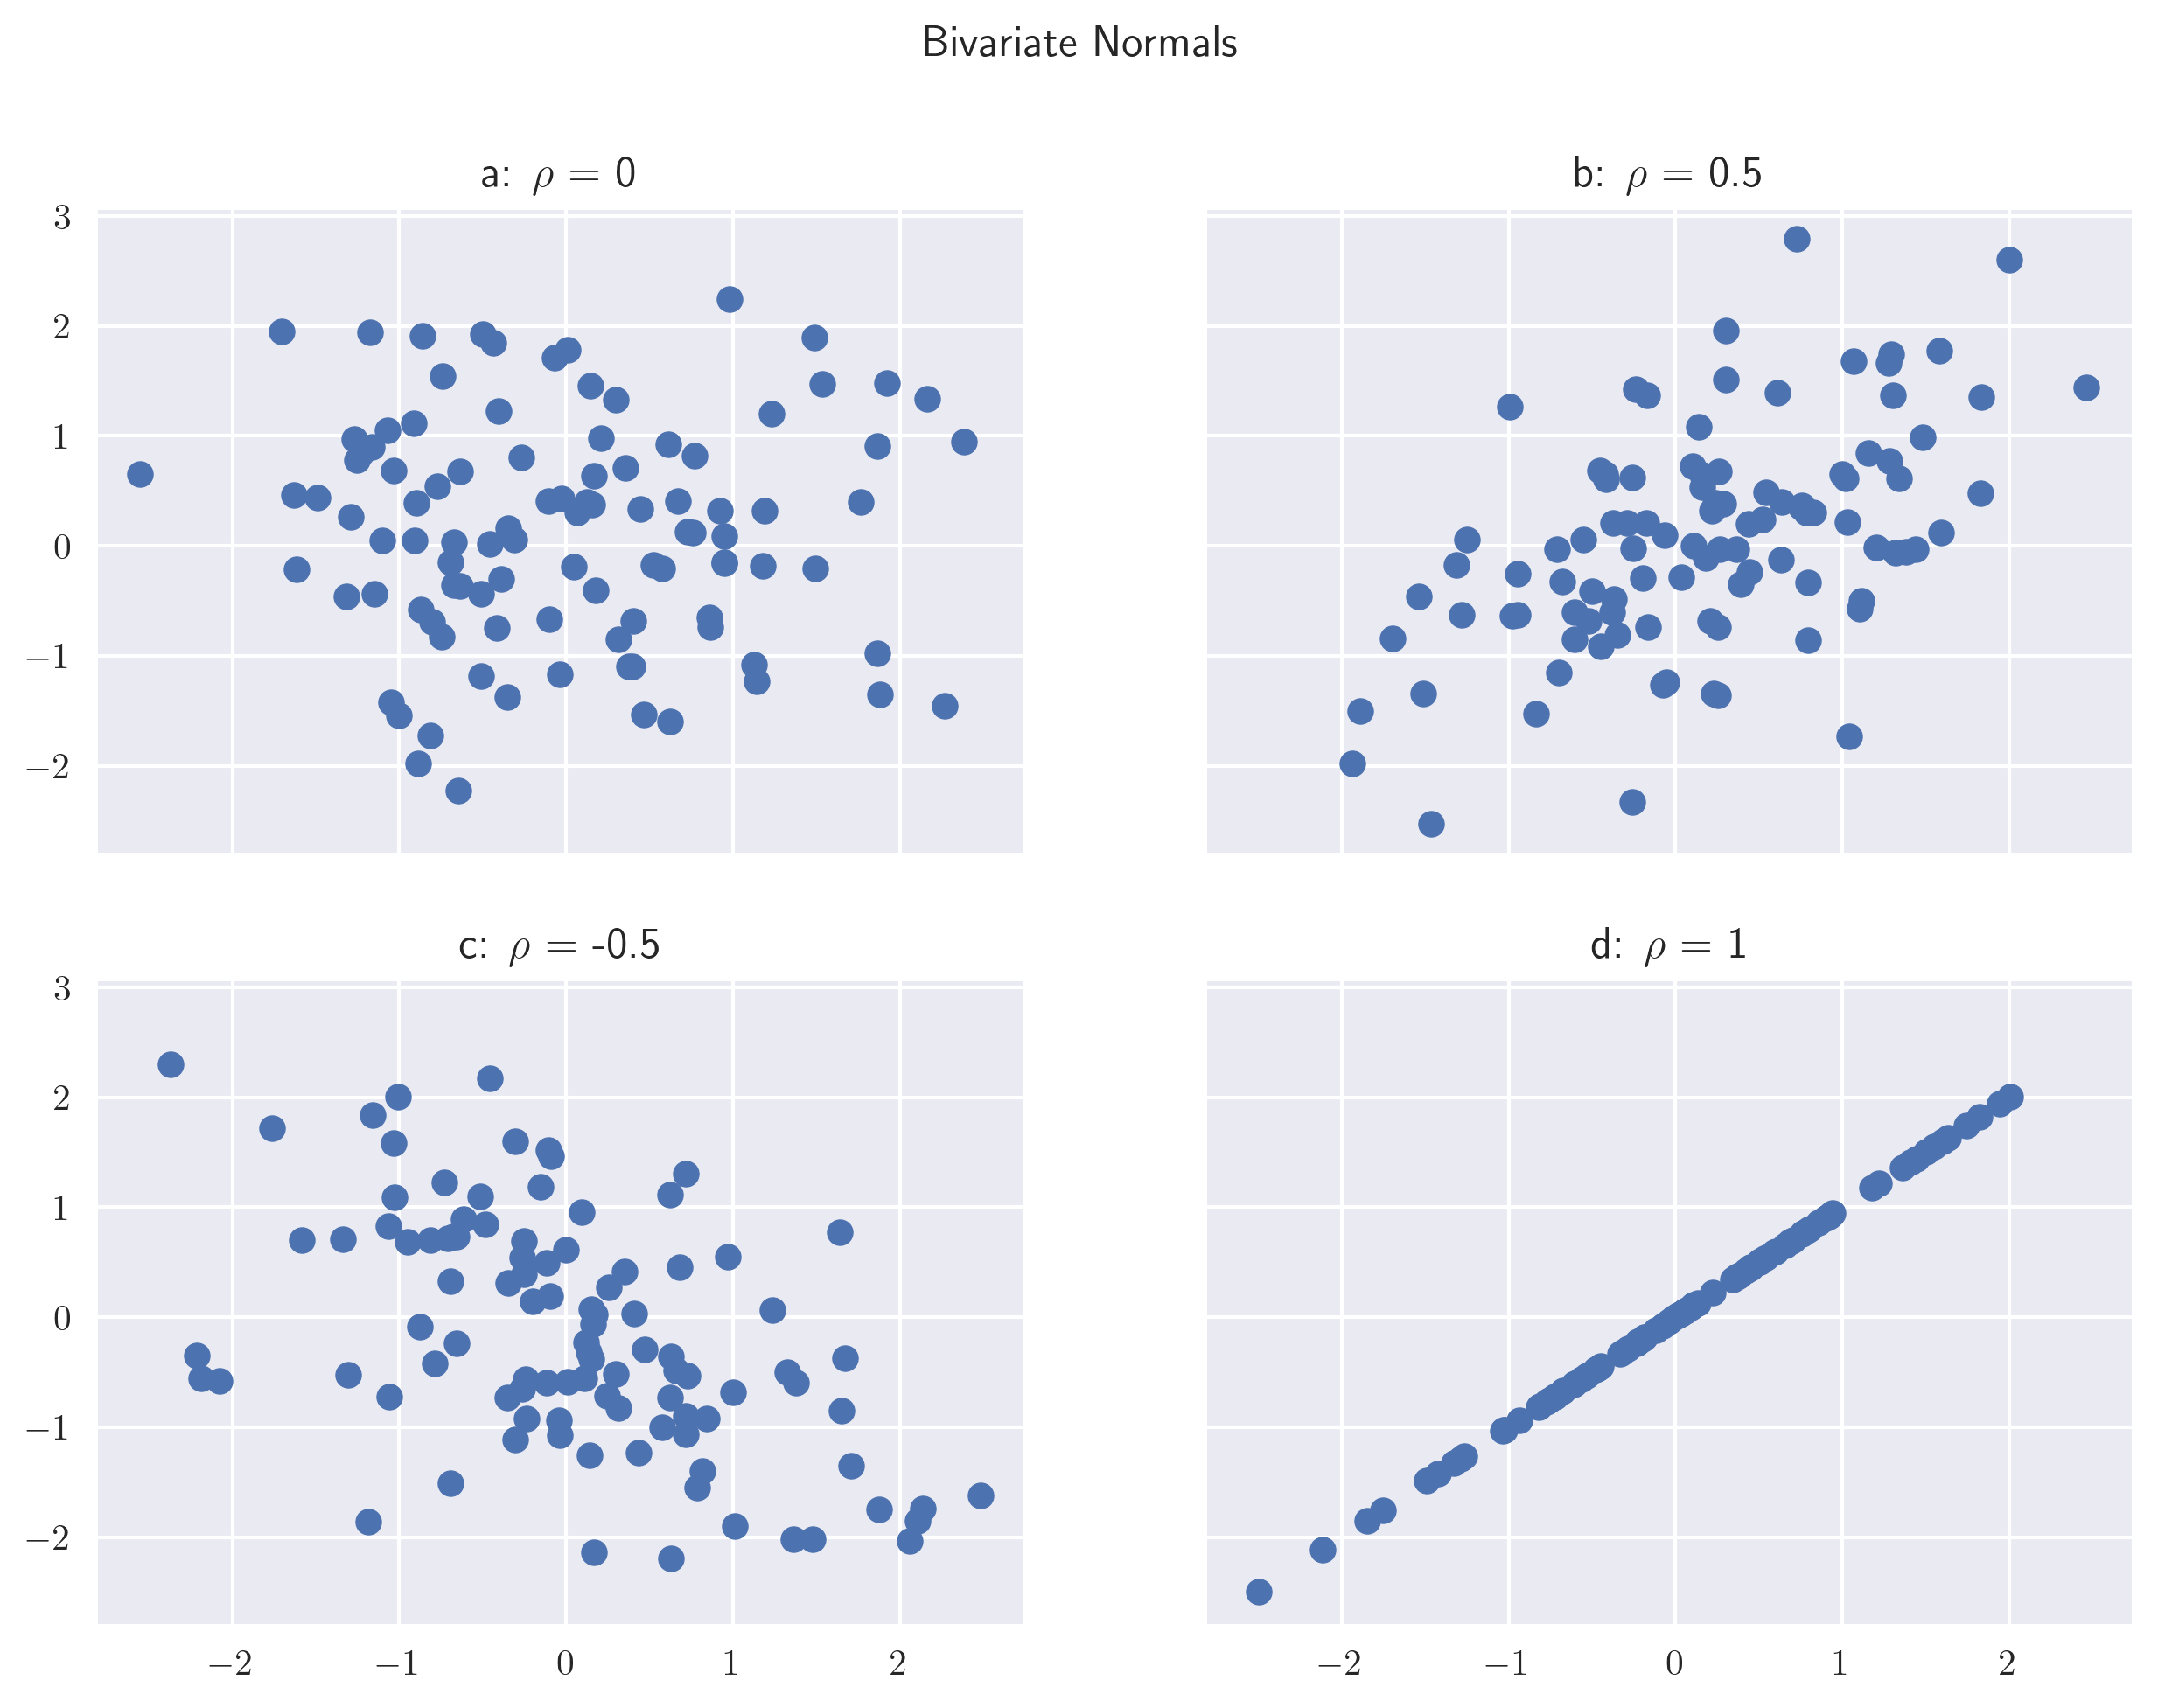

In [5]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Create list for problem parts
parts = ['a', 'b', 'c', 'd']

# Define mu
mu = np.zeros(2)

# Create list of covariance matrices
covs = [np.array([[1, 0], [0, 1]]), 
        np.array([[1, 0.5], [0.5, 1]]), 
        np.array([[1, -0.5], [-0.5, 1]]), 
        np.array([[1, 1], [1, 1]])]

# Set up subplots
fig, ax = plt.subplots(2, 2, sharex = True, sharey = True, 
                       figsize = (10, 7))

# Loop over titles and covariance matrices
for i, part, cov in zip(range(4), parts, covs):
    
    # Get the row and column
    row, col = i // 2, i % 2

    # Generate sample
    sample = multivariate_normal.rvs(mean = mu, 
                                   cov = cov, size = 100)
    
    # Get x- and y-coordinates
    x, y = zip(*sample)
    
    # Plot the values
    ax[row, col].scatter(x, y)
    
    # Get title
    title = rf'{part}: $\rho$ = {cov[0, 1]}'
    
    # Give the plot a title
    ax[row, col].title.set_text(title)

# Give entire figure title
fig.suptitle('Bivariate Normals')

# Save the figure
plt.savefig(path + r'ex4-1.png')

plt.show()

In [8]:
# Import modules
import pandas as pd

# Load in data; make date the index
data = pd.read_csv(data_path, index_col = 'Date')

# Get covariance matrix
S = data.cov()

S

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
A,0.000362,0.000203,0.000114,0.000170,0.000157,0.000203,0.000228,0.000256,0.000133,0.000169,...,0.000138,0.000242,0.000237,0.000106,0.000128,0.000212,0.000131,0.000157,0.000286,0.000209
AAPL,0.000203,0.000426,0.000100,0.000149,0.000158,0.000226,0.000307,0.000296,0.000130,0.000192,...,0.000153,0.000255,0.000267,0.000122,0.000134,0.000203,0.000146,0.000149,0.000301,0.000202
ABBV,0.000114,0.000100,0.000253,0.000116,0.000125,0.000107,0.000100,0.000111,0.000093,0.000116,...,0.000093,0.000140,0.000112,0.000091,0.000110,0.000100,0.000090,0.000113,0.000105,0.000122
ABT,0.000170,0.000149,0.000116,0.000268,0.000136,0.000155,0.000165,0.000160,0.000109,0.000154,...,0.000128,0.000185,0.000110,0.000130,0.000080,0.000152,0.000114,0.000139,0.000170,0.000170
ACGL,0.000157,0.000158,0.000125,0.000136,0.000446,0.000192,0.000147,0.000196,0.000199,0.000212,...,0.000193,0.000287,0.000296,0.000147,0.000223,0.000226,0.000172,0.000194,0.000204,0.000154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.000212,0.000203,0.000100,0.000152,0.000226,0.000211,0.000199,0.000266,0.000172,0.000205,...,0.000170,0.000295,0.000284,0.000135,0.000180,0.000379,0.000165,0.000185,0.000269,0.000178
YUM,0.000131,0.000146,0.000090,0.000114,0.000172,0.000150,0.000132,0.000173,0.000127,0.000150,...,0.000140,0.000229,0.000254,0.000112,0.000137,0.000165,0.000272,0.000167,0.000161,0.000148
ZBH,0.000157,0.000149,0.000113,0.000139,0.000194,0.000171,0.000138,0.000194,0.000150,0.000154,...,0.000141,0.000241,0.000314,0.000100,0.000183,0.000185,0.000167,0.000389,0.000198,0.000154
ZBRA,0.000286,0.000301,0.000105,0.000170,0.000204,0.000273,0.000311,0.000377,0.000176,0.000222,...,0.000165,0.000339,0.000361,0.000105,0.000189,0.000269,0.000161,0.000198,0.000680,0.000241


## Principal Component Analysis (PCA)

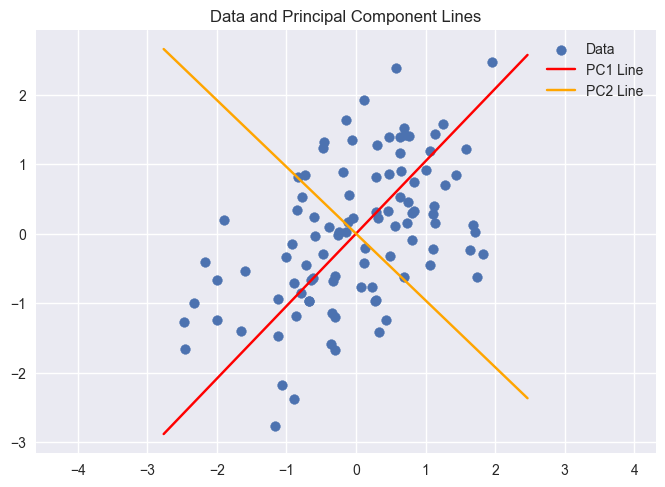

The product of the slopes of perpendicular lines is -1, and m_1 * m_2 = -1.00000.


In [5]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Get covariance matrix
cov = np.array([[1, 0.5], [0.5, 1]])

# Generate data
X = multivariate_normal.rvs(mean = np.zeros(2), 
                            cov = cov, size = 100)

# Demean data, though mean already close to zero
X -= X.mean(axis = 0)

# Calculate covariance matrix
S = np.cov(X, rowvar = False, ddof = 1)

# Get eigenvalues and eigenvectors
evals, evecs = np.linalg.eigh(S)

# Index to sort eigenvalues into descending order
idx = evals.argsort()[::-1]

# Sort eigenvalues and -vectors
evals, evecs = evals[idx], evecs[:, idx]

# Get slopes
m_1, m_2 = evecs[1, 0]/evecs[0, 0], evecs[1, 1]/evecs[0, 1]

# Get x-values for plot
x_vals = np.linspace(X.min(), X.max())

# Plot graph
plt.scatter(*X.T, label = 'Data')
plt.plot(x_vals, m_1 * x_vals, color = 'red', label = 'PC1 Line')
plt.plot(x_vals, m_2 * x_vals, color = 'orange', label = 'PC2 Line')

# Add legend
plt.legend()

# Make aspect ratio the same, so PCs look perp
plt.axis('equal')

# Add title
plt.title('Data and Principal Component Lines')

# Save the figure
plt.savefig(path + r'ex4-2.png')

plt.show()

# Check to make sure lines perpendicular
print(f'The product of the slopes of perpendicular lines is -1, and m_1 * m_2 = {m_1 * m_2:0.5f}.')

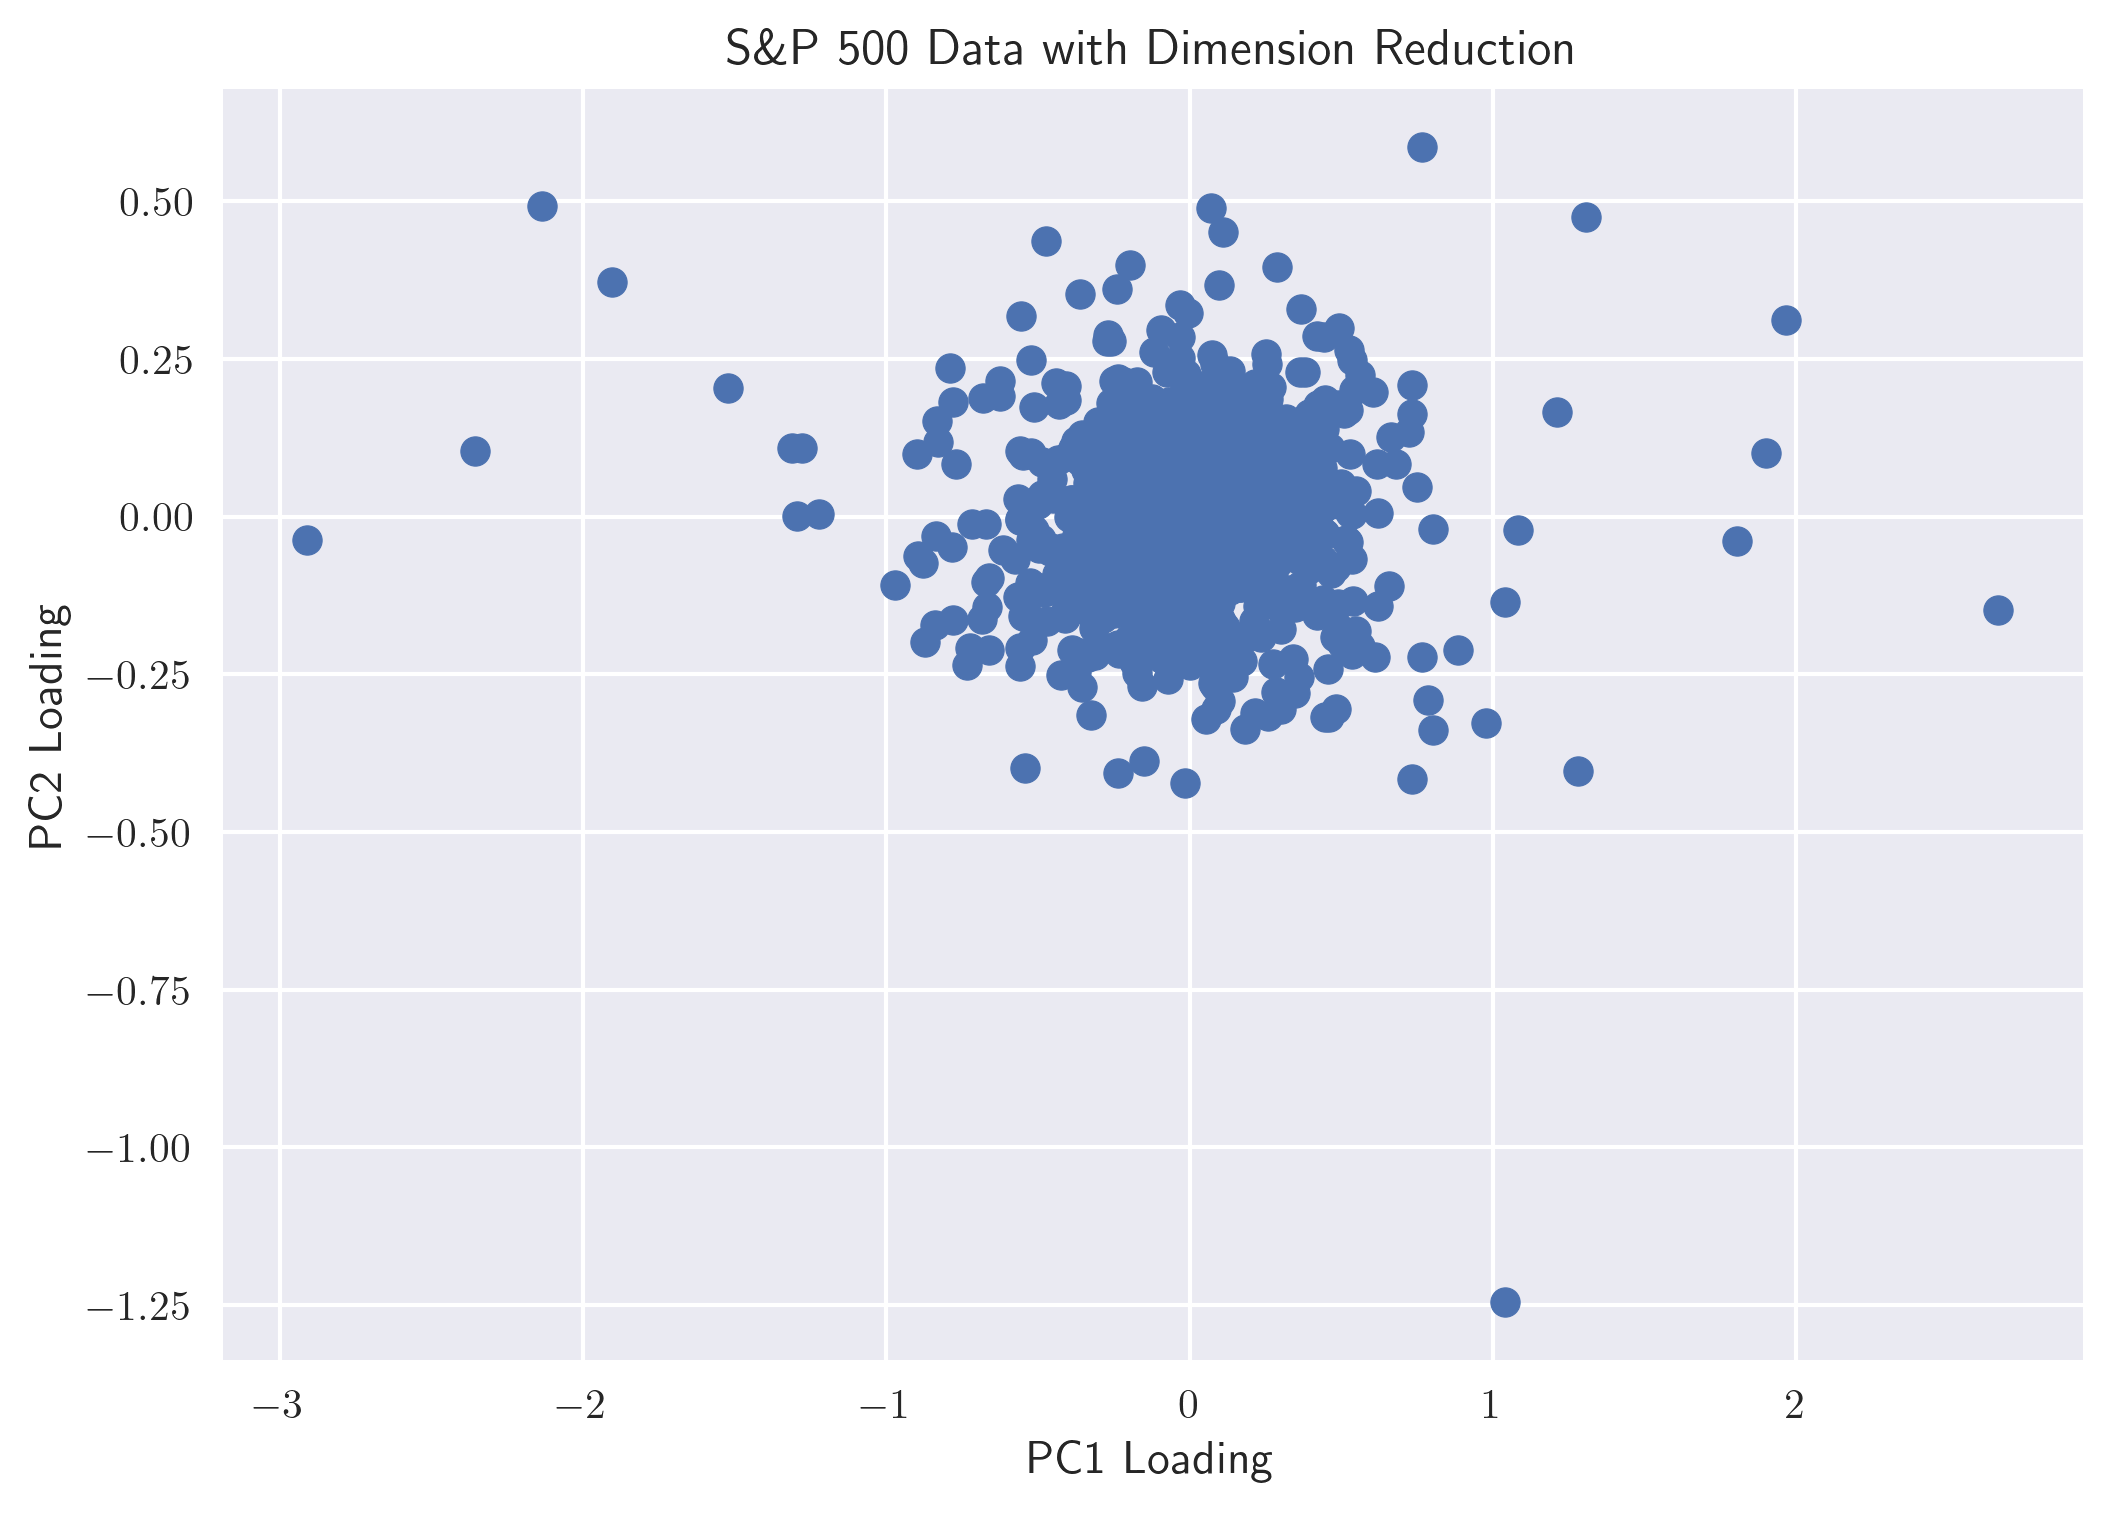

In [11]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt

# Increase resolution
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Get S&P 500 return cov matrix
S = data.cov()

# Get the eigenvalues and eigenvectors
evals, evecs = np.linalg.eigh(S)

# Index to sort eigenvalues into descending order
idx = evals.argsort()[::-1]

# Change order
evals, evecs = evals[idx], evecs[:, idx]

# Convert the observations to a numpy array
X = data.values

# Demean X
X -= X.mean(axis = 0)

# Calculate loadings using the dot product
loadings = X @ evecs[:, 0:2]

# Unpack results
x, y = zip(*loadings)

# Get scatter plot
plt.scatter(x, y)

# Create x- and y-labels
plt.xlabel('PC1 Loading')
plt.ylabel('PC2 Loading')

# Give the plot a title
plt.title(r'S\&P 500 Data with Dimension Reduction')

# Save the figure
plt.savefig(path + r'ex4-3.png')

plt.show()


## Clipping Covariance Matrices

In [13]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set the random seed
np.random.seed(0)

# Generate normal random variables
X = norm.rvs(size = (50, 100))

# Get the covariance matrix
S = np.cov(X, rowvar = False, ddof = 1)

# Get the eigenvalues
evals, _ =  np.linalg.eigh(S)

print(f'The sample covariance matrix has {np.sum(np.isclose(evals, 0))}',
      r'eigenvalues numerically indistinguishable from 0.')

The sample covariance matrix has 51 eigenvalues numerically indistinguishable from 0.


In [14]:
# Get the standard deviations
stds = np.sqrt(np.diag(S))

# Get the correlation matrix
C = np.diag(1/stds) @ S @ np.diag(1/stds)

# Get the eigenvalues and vectors of C
evals_c, evecs_c = np.linalg.eigh(C)

# Let lam_min be a small positive number outside of np.isclose threshold
lam_min = 1e-7

# Replace eigenvalues that are too small
evals_c[evals_c < lam_min] = lam_min

# Reconstruct correlation matrix
C_new = evecs_c @ np.diag(evals_c) @ evecs_c.T

# Make sure still correlation matrix
C_new = (np.diag(np.sqrt(1/np.diag(C_new))) @ C_new
            @ np.diag(np.sqrt(1/np.diag(C_new))))

# Multiply by standard deviations to make it a covariance matrix
S_new = np.diag(stds) @ C_new @ np.diag(stds)

# Get the eigenvalues
evals_new, _ =  np.linalg.eigh(S_new)

print(f'The new covariance matrix has {np.sum(np.isclose(evals_new, 0))}',
      r'eigenvalues numerically indistinguishable from 0.')

The new covariance matrix has 0 eigenvalues numerically indistinguishable from 0.


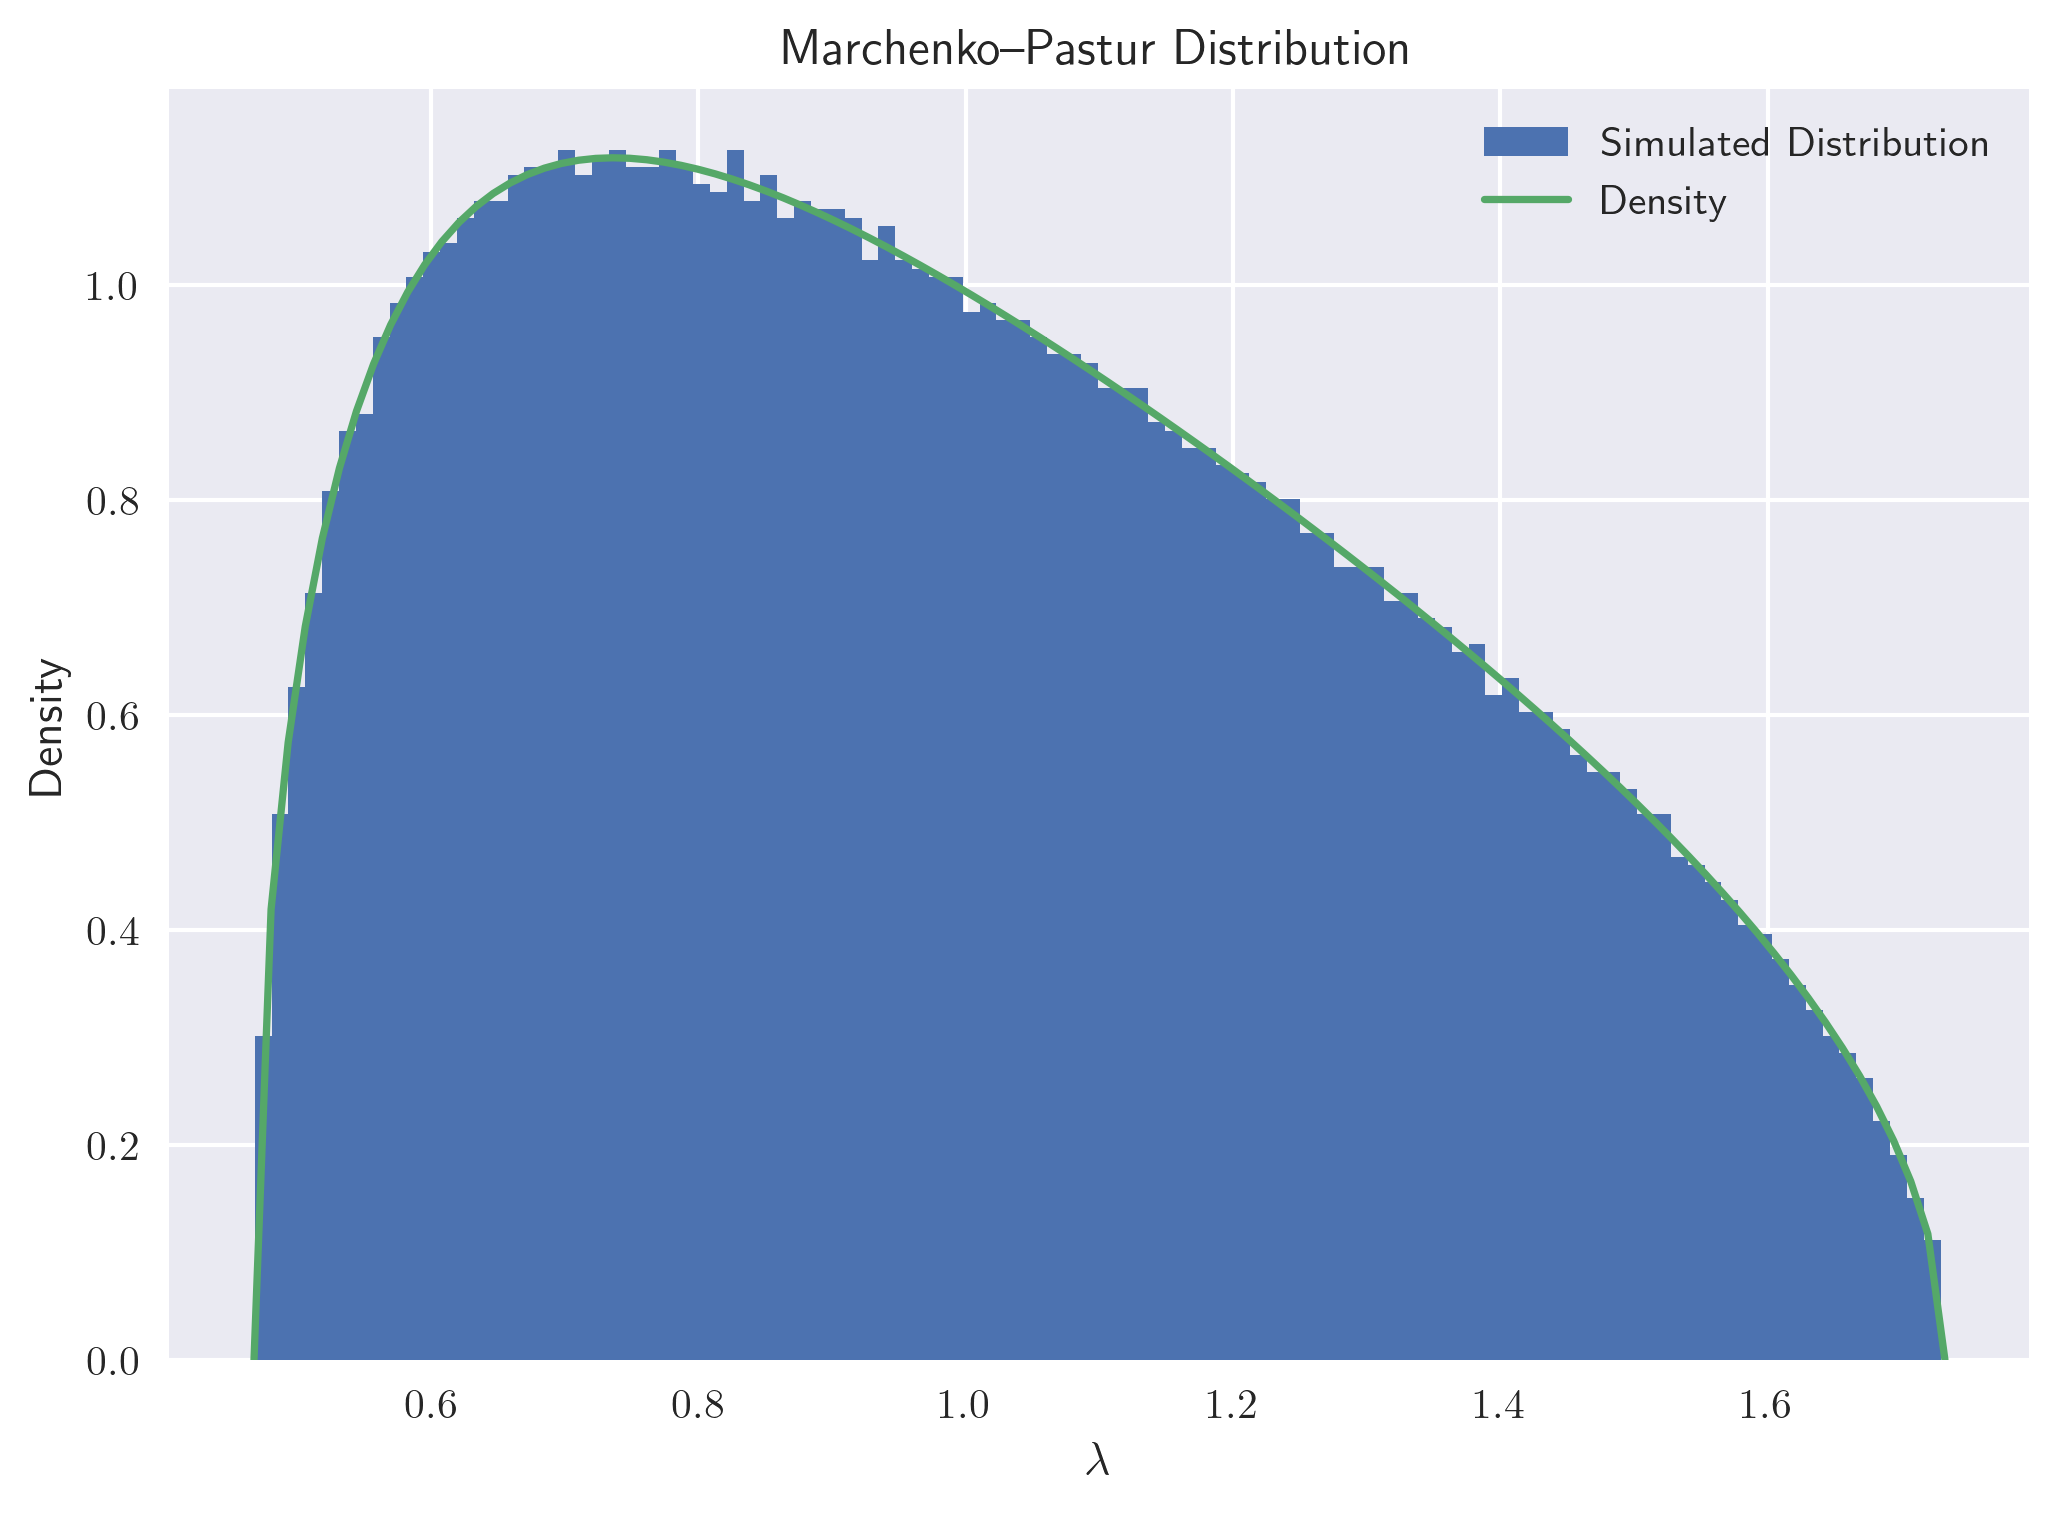

This script took 2.66 minutes to run.


In [7]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Start the clock
start_time = time.perf_counter()

# Generate normal random variables
X = norm.rvs(size = (100_000, 10_000))

# Get the number of observations and variables
T, N = X.shape

# Get correlation matrix
C = np.corrcoef(X, rowvar = False)

# Clear up RAM
del X

# q is the number of observations divided by the number of variables
q = T/N

# Get eigenvalues
evals, _ = np.linalg.eigh(C)

# Get support of Marchenko–Pastur distribution
lam_minus, lam_plus = (1 - np.sqrt(1/q))**2, (1 + np.sqrt(1/q))**2 
        
# Define pdf
def f(lam):
    
    # Support of Marchenko–Pastur distribution
    if lam_minus <= lam <= lam_plus:
    
        return q/(2 * np.pi) * np.sqrt((lam_plus - lam) * (lam - lam_minus))/lam
                
    else:
        
        return 0

# Get lam_vals
lam_vals = np.linspace(lam_minus, lam_plus, 100)

# Get density values
f_vals = [f(lam) for lam in lam_vals]

# Plot histogram
plt.hist(evals, density = True, bins = int(np.sqrt(N)), label = 'Simulated Distribution')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density')

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'Marchenko–Pastur Distribution')

# Save the figure
plt.savefig(path + r'ex4-4.png')

plt.show()

print(f'This script took {(time.perf_counter() - start_time)/60:.2f} minutes to run.')

There are 3 eigenvalues greater than 10.


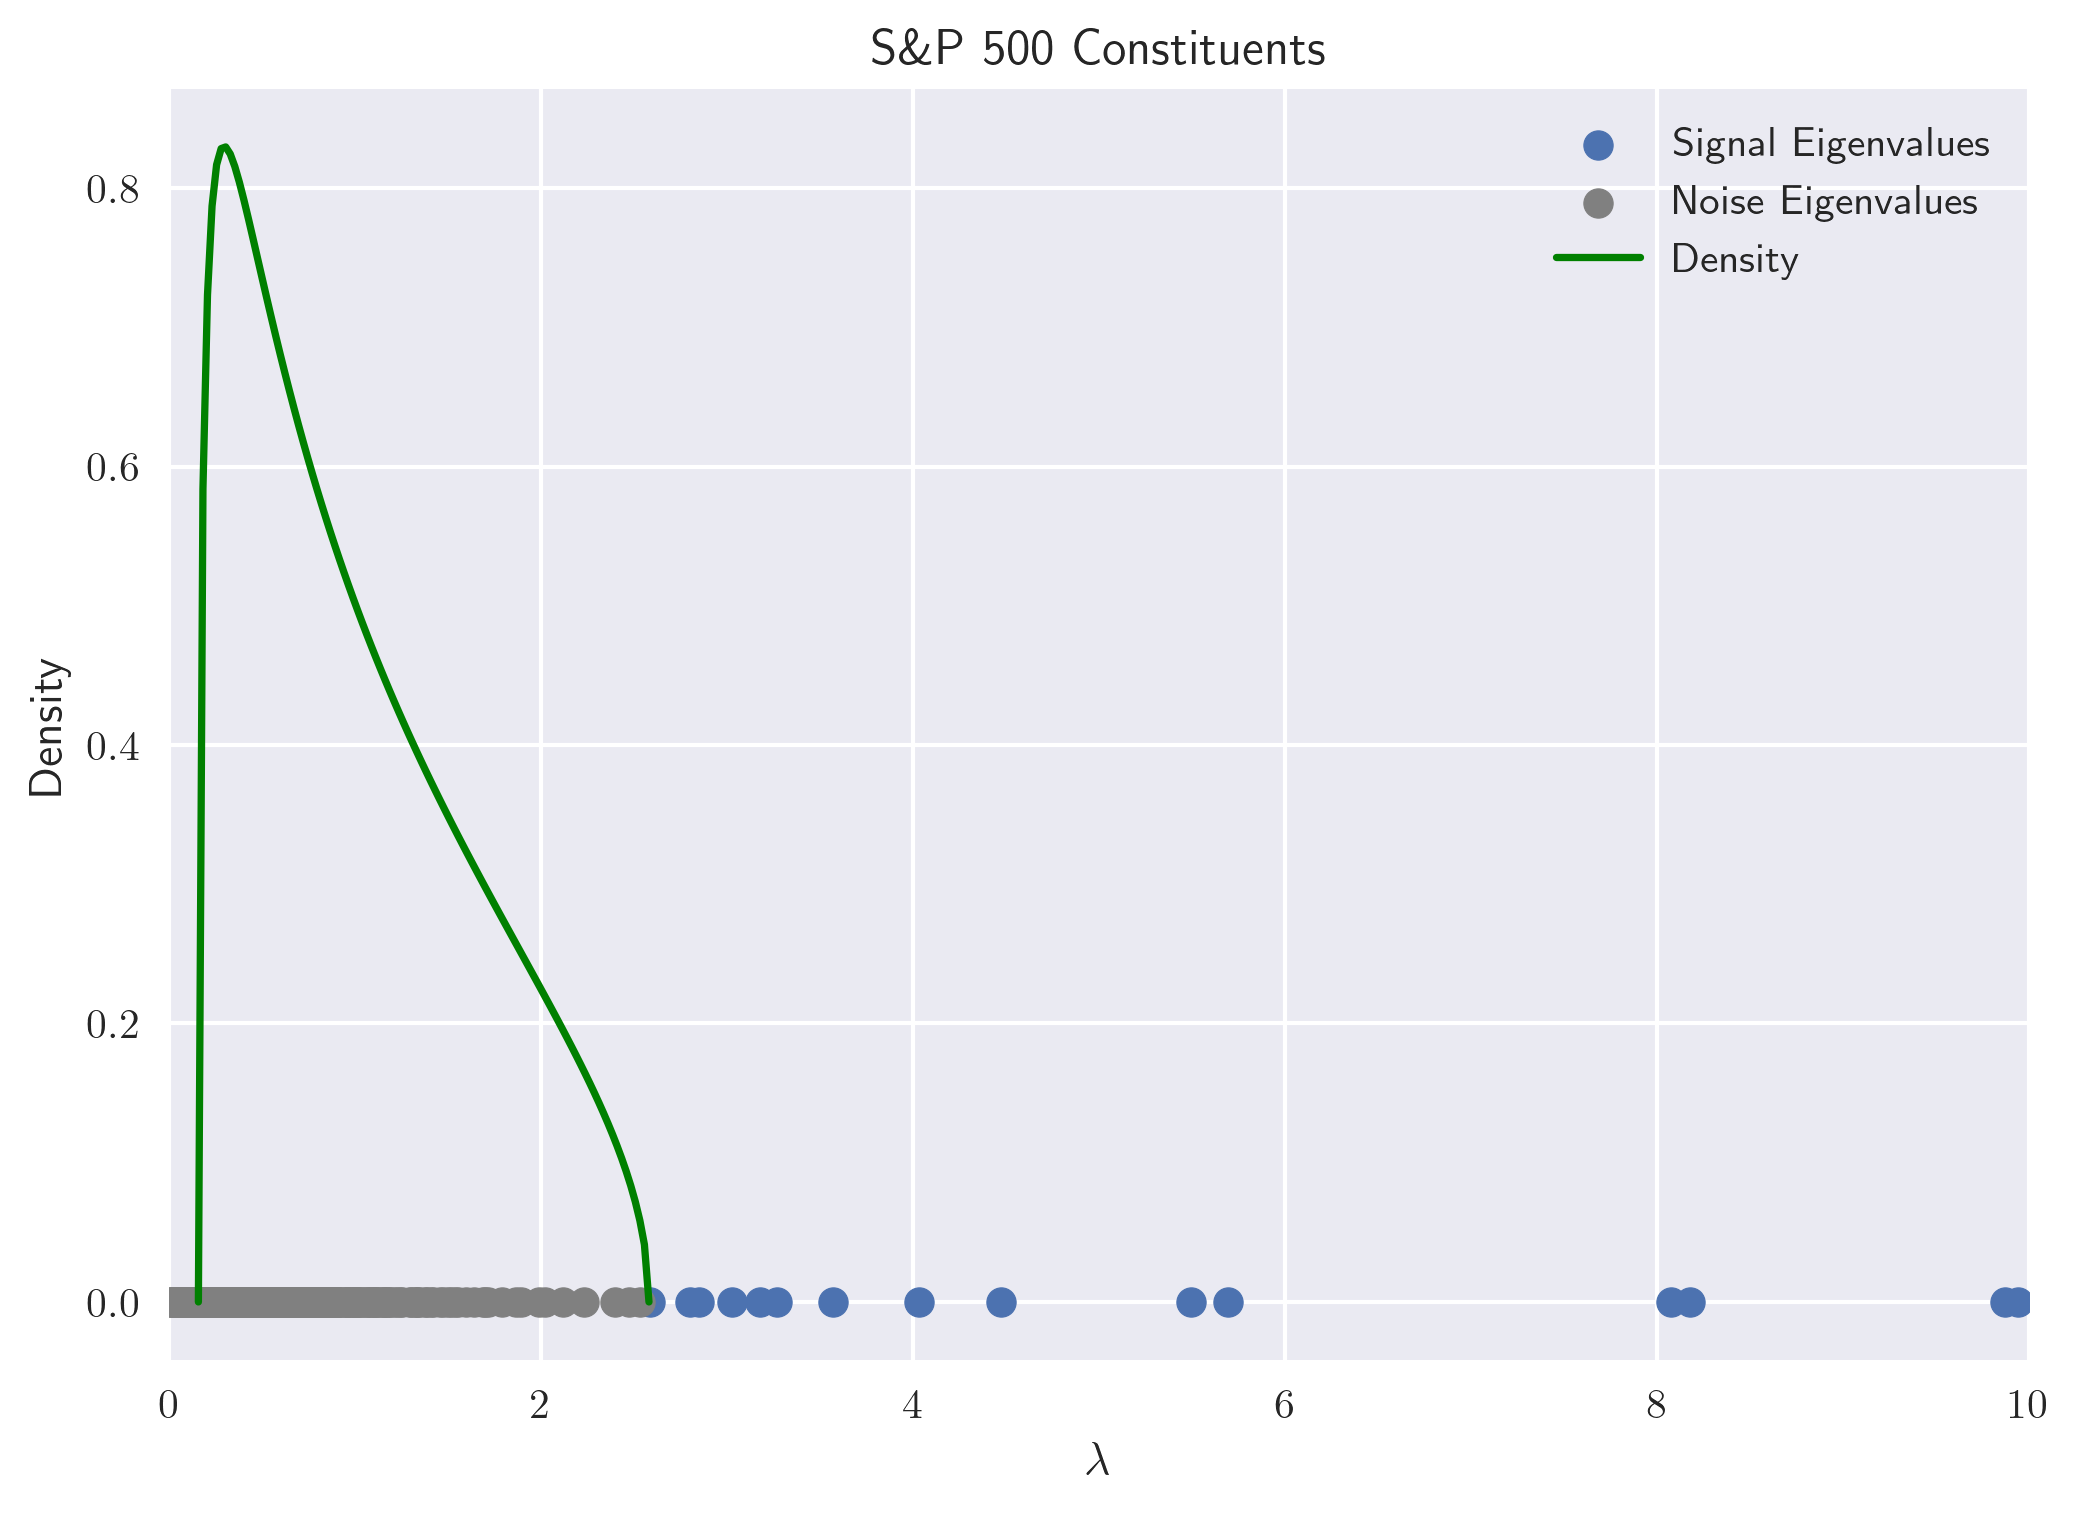

In [21]:
# Import modules
import pandas as pd

# Load in data
data = pd.read_csv(data_path, index_col = 'Date')

# Get covariance matrix; convert to numpy array
S = data.cov().values

# Get the standard deviations
stds = np.sqrt(np.diag(S))

# Calculate correlation matrix
C = np.diag(1/stds) @ S @ np.diag(1/stds)

# Get the eigenvalues and vectors
evals, evecs =  np.linalg.eigh(C)

# Save q
q = data.shape[0]/data.shape[1]

# Get support of Marchenko–Pastur distribution
lam_minus, lam_plus = (1 - np.sqrt(1/q))**2, (1 + np.sqrt(1/q))**2 
        
# Define pdf
def f(lam):
    
    # Suppose of Marchenko–Pastur distribution
    if lam_minus <= lam <= lam_plus:
    
        return q/(2 * np.pi) * np.sqrt((lam_plus - lam) * (lam - lam_minus))/lam
                
    else:
        
        return 0
    
# Get lam_vals
lam_vals = np.linspace(lam_minus, lam_plus, 100)

# Get density values
f_vals = [f(lam) for lam in lam_vals]

# Plot eigenvalues that are signal
plt.scatter(evals[evals > lam_plus], np.zeros(np.sum(evals > lam_plus)), 
            label = 'Signal Eigenvalues')

# Plot eigenvalues that are noise
plt.scatter(evals[evals <= lam_plus], np.zeros(np.sum(evals <= lam_plus)), 
            label = 'Noise Eigenvalues', color = 'gray')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density', color = 'green')

# There are 3 (?) eigenvalues much larger than 10
plt.xlim([0, 10])

# Check this since updating data each year
print(f'There are {np.sum(evals > 10)} eigenvalues greater than 10.')

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'S\&P 500 Constituents')

# Save the figure
plt.savefig(path + r'ex4-5.png')

plt.show()

In [23]:
# Initialize new eigenvalues
evals_new = evals.copy()

# Replace noise eigenvalues with mean
evals_new[evals_new < lam_plus] = np.mean(evals_new[evals_new < lam_plus])

# Construct new correlation matrix
C_new = evecs @ np.diag(evals_new) @ evecs.T

# Make sure still correlation matrix
C_new = np.diag(1/np.sqrt(np.diag(C_new))) @ C_new @ np.diag(1/np.sqrt(np.diag(C_new)))

# Make new covariance matrix
S_new = np.diag(stds) @ C_new @ np.diag(stds)

There are 3 eigenvalues greater than 10.


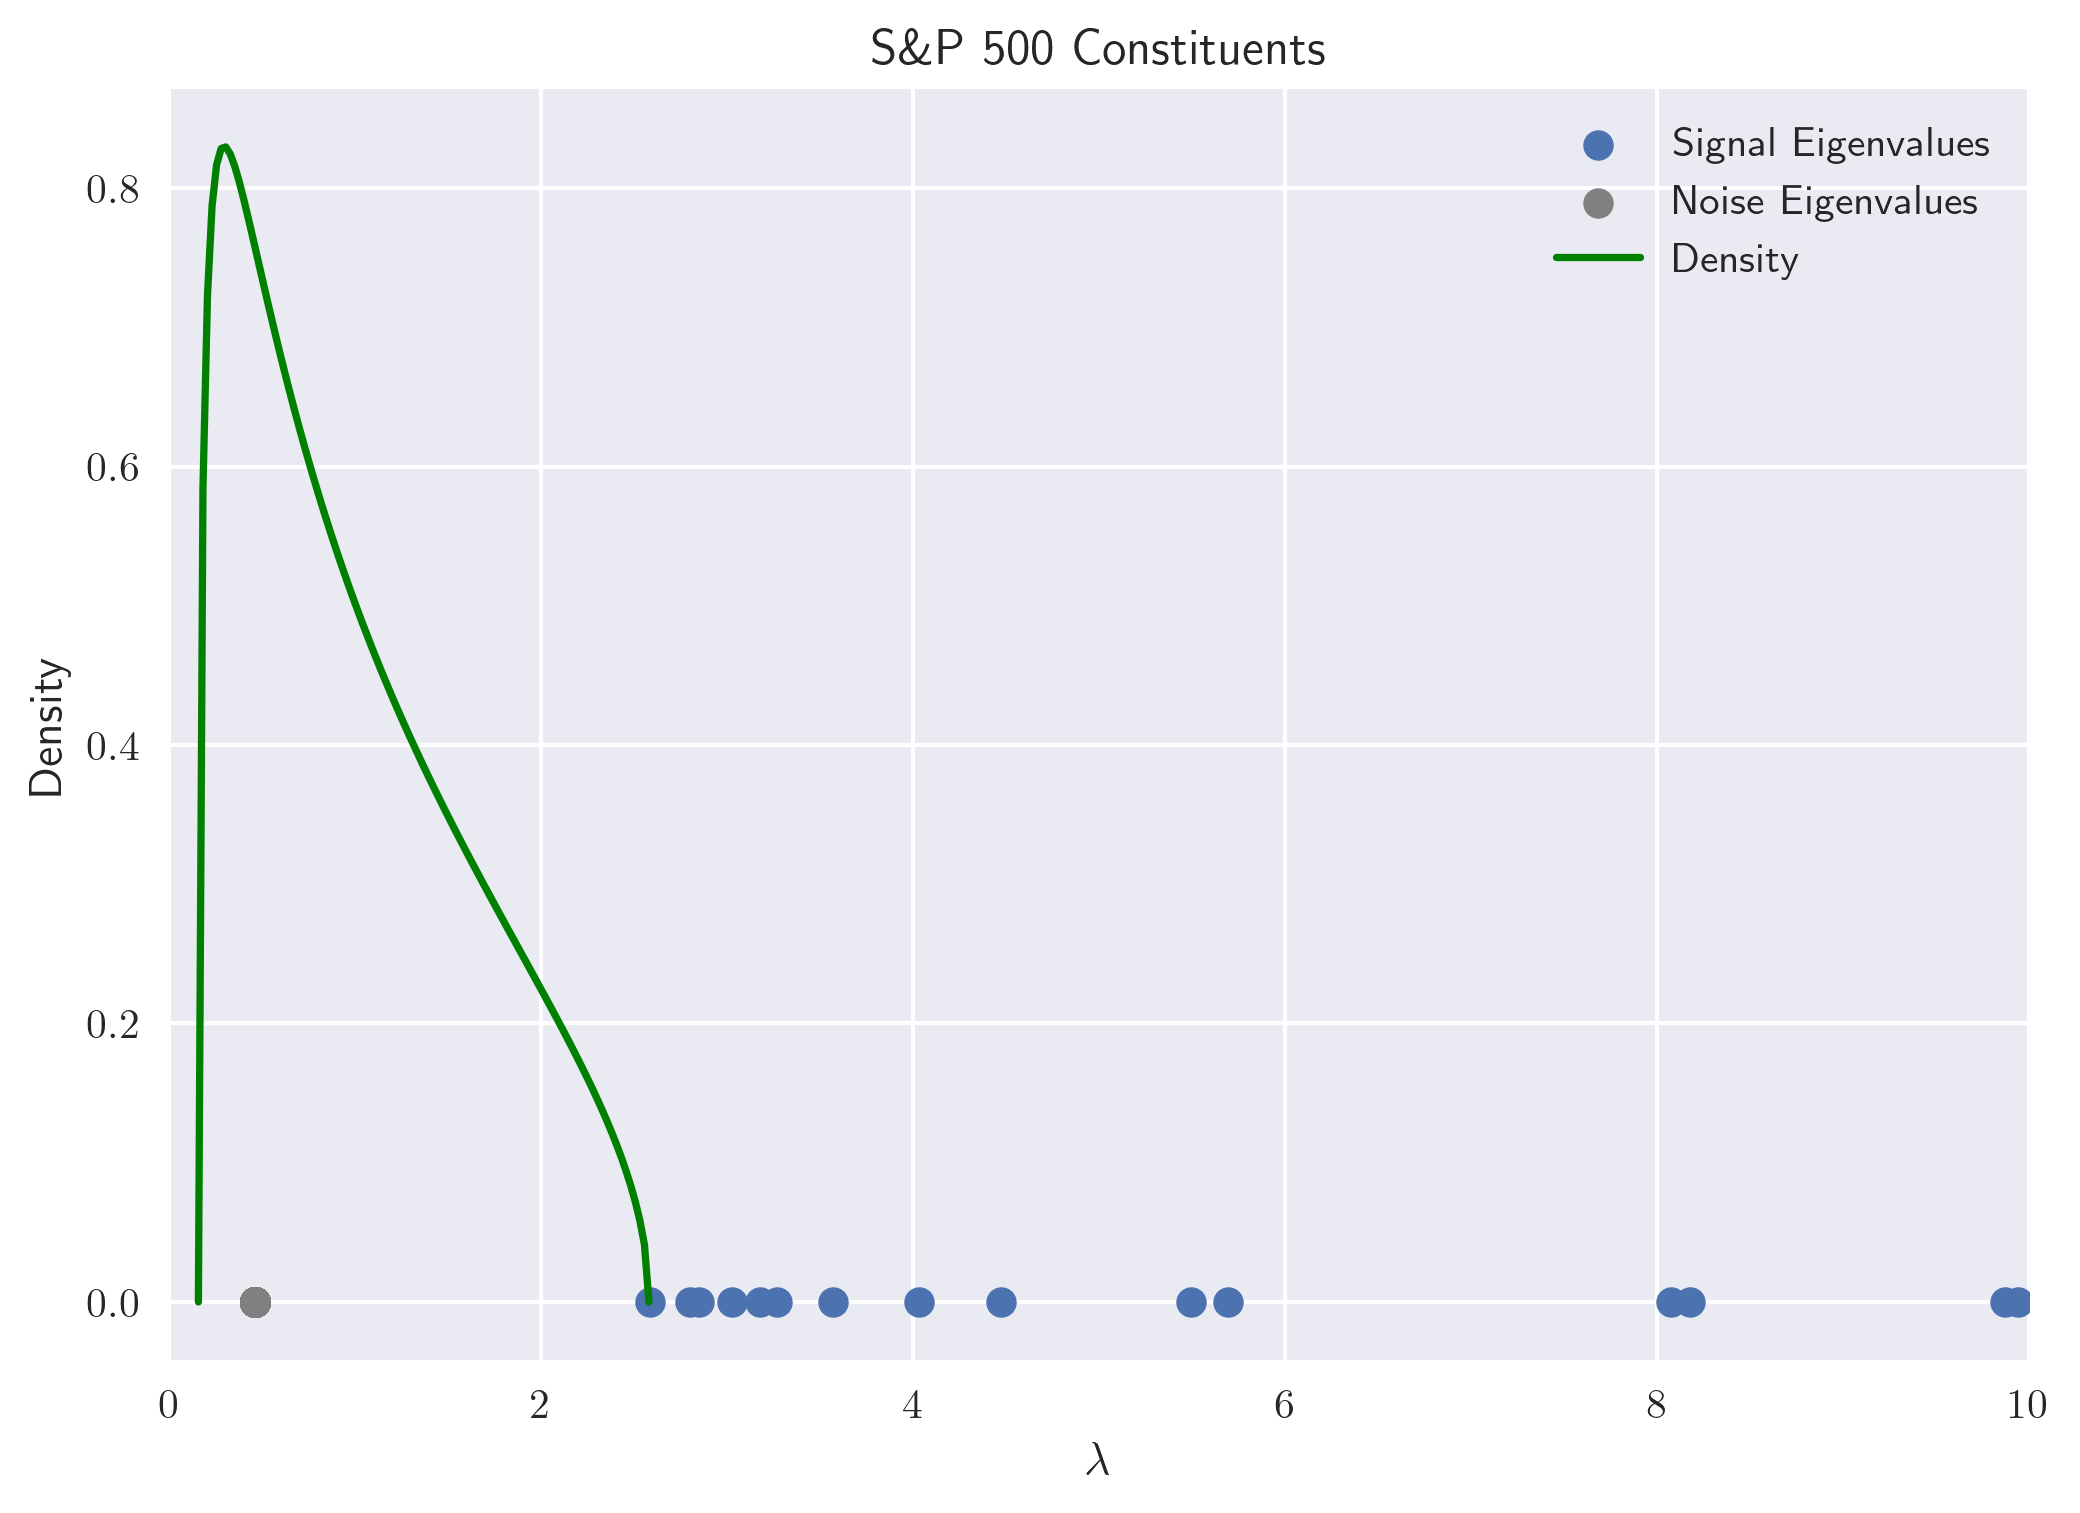

In [27]:
# Plot eigenvalues that are signal
plt.scatter(evals_new[evals_new > lam_plus], np.zeros(np.sum(evals_new > lam_plus)), 
            label = 'Signal Eigenvalues')

# Plot eigenvalues that are noise
plt.scatter(evals_new[evals_new <= lam_plus], np.zeros(np.sum(evals_new <= lam_plus)), 
            label = 'Noise Eigenvalues', color = 'gray')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density', color = 'green')

# There are 3 (?) eigenvalues much larger than 10
plt.xlim([0, 10])

# Check this since updating data each year
print(f'There are {np.sum(evals > 10)} eigenvalues greater than 10.')

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'S\&P 500 Constituents')

# Save the figure
plt.savefig(path + r'ex4-6.png')

plt.show()

## Stochastic Calculus

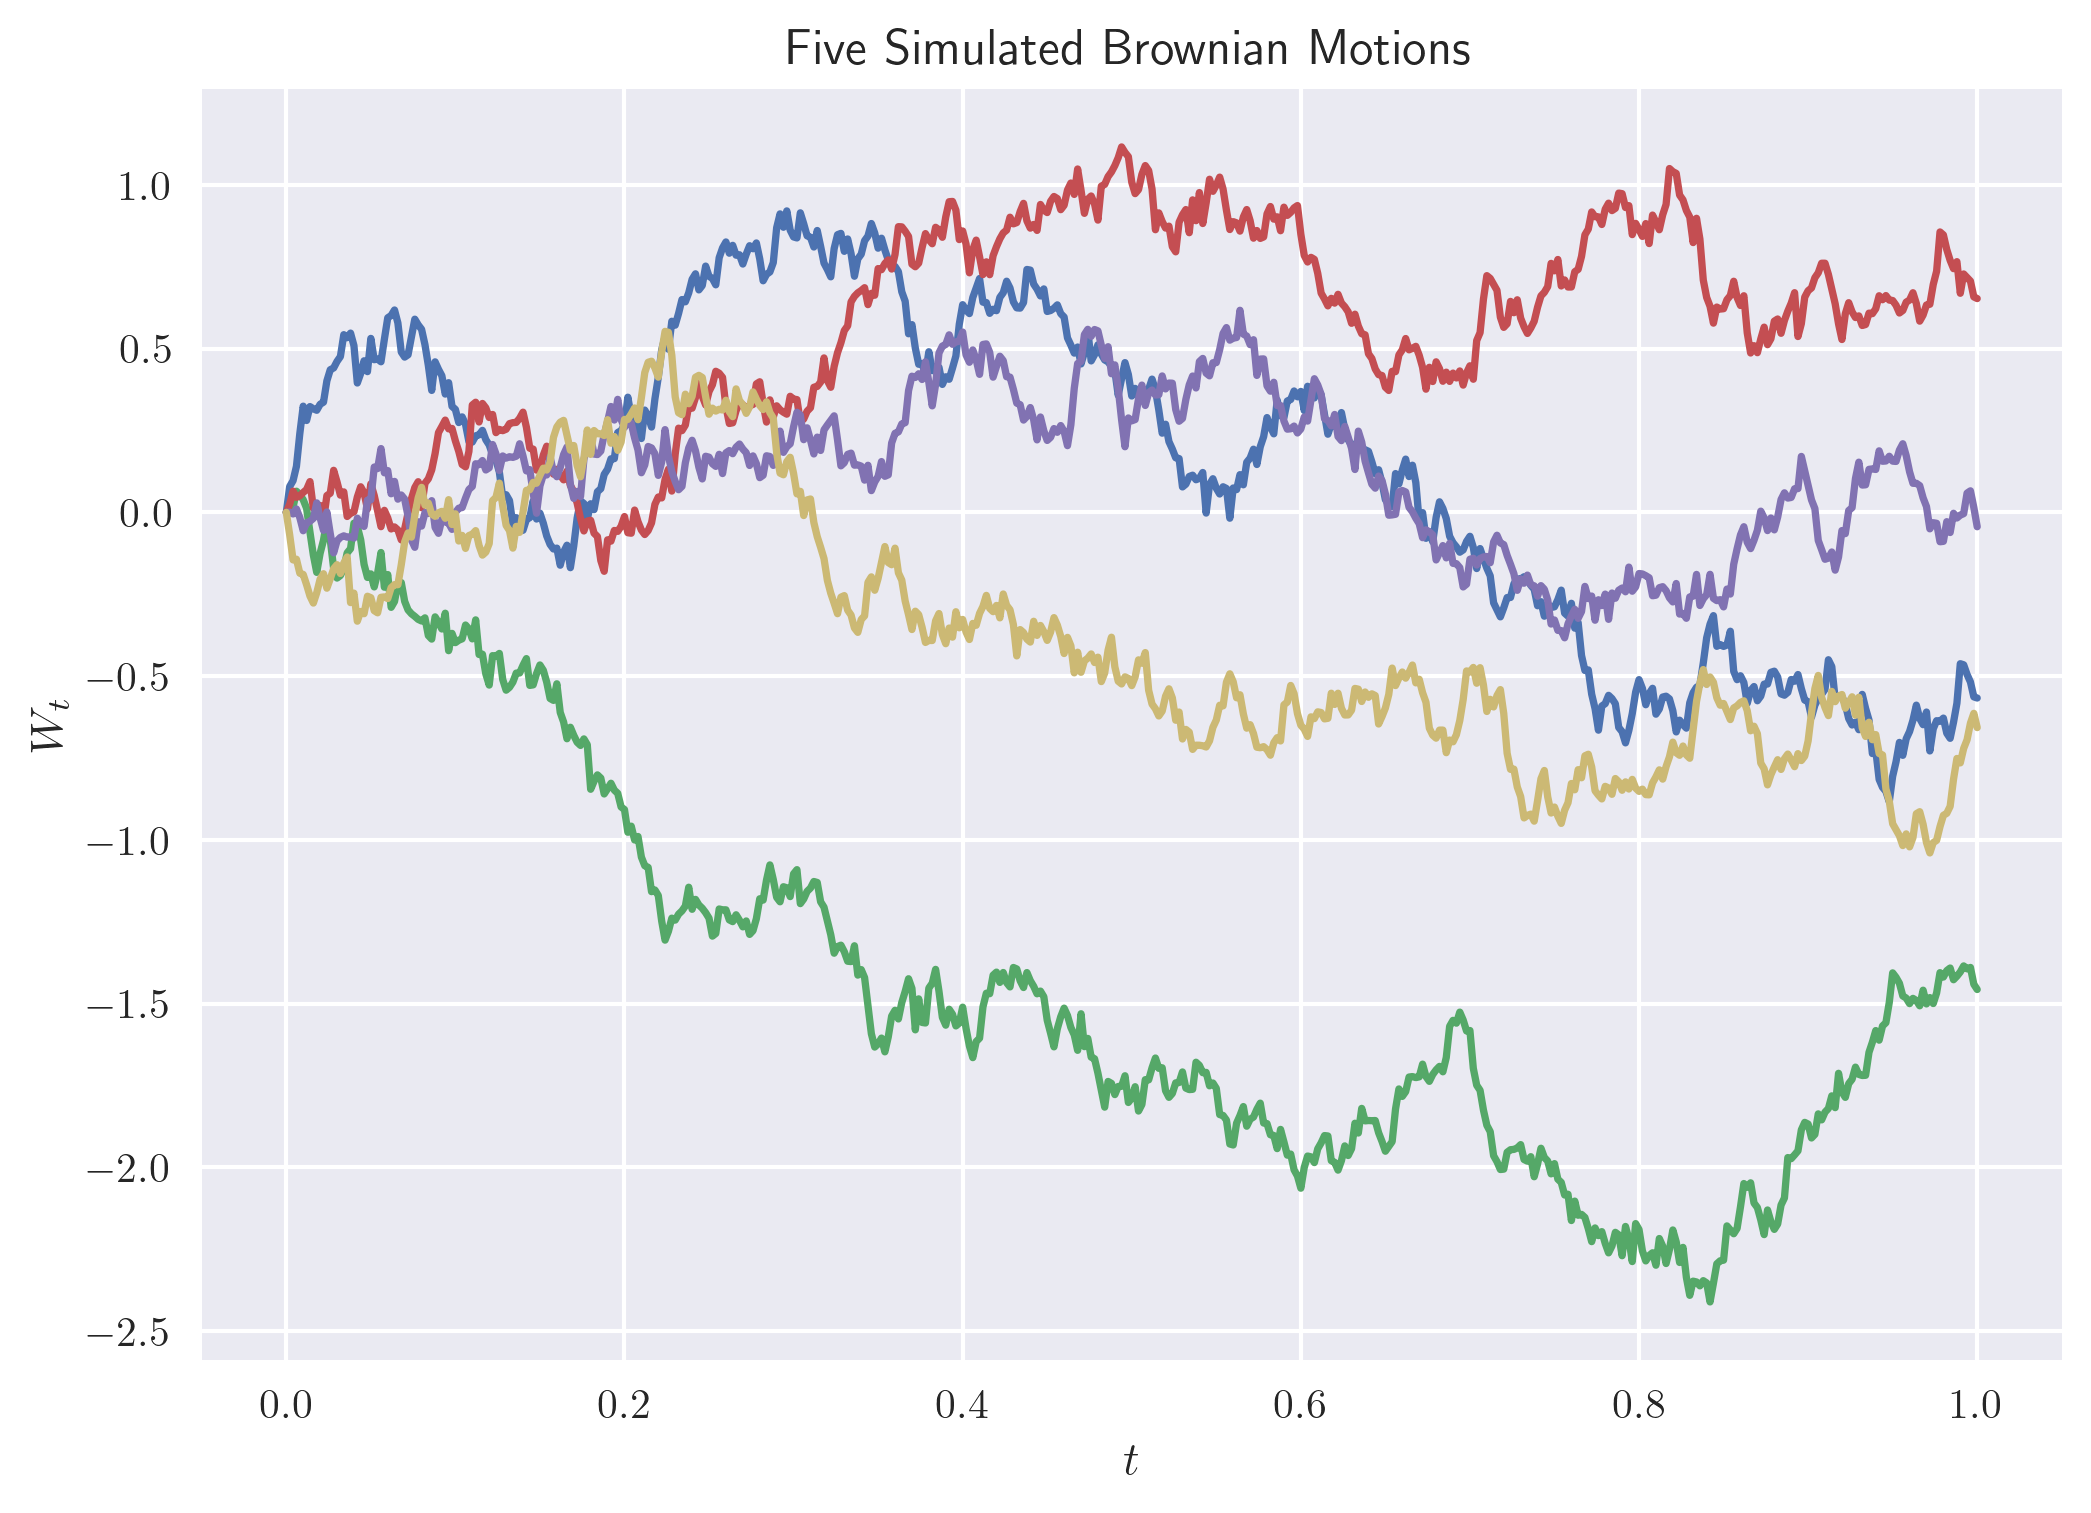

In [29]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Break up so exact BM at n + 1 times
n = 500

# Simulate five Brownian motions
for _ in range(5):
    
    # Simulate Brownian motion for t in [0, 1]
    dW = norm.rvs(scale = np.sqrt(1/n), size = n)
    
    # Take the cumulative sum; add 0 for the t = 0 value
    W = np.insert(np.cumsum(dW), 0, 0)
    
    # Plot results
    plt.plot(np.linspace(0, 1, n + 1), W)
    
# Add x-label
plt.xlabel(r'$t$')

# Add y-label
plt.ylabel(r'$W_t$')

# Add title to plot
plt.title(r'Five Simulated Brownian Motions')

# Save the figure
plt.savefig(path + r'ex4-7.png')

plt.show()

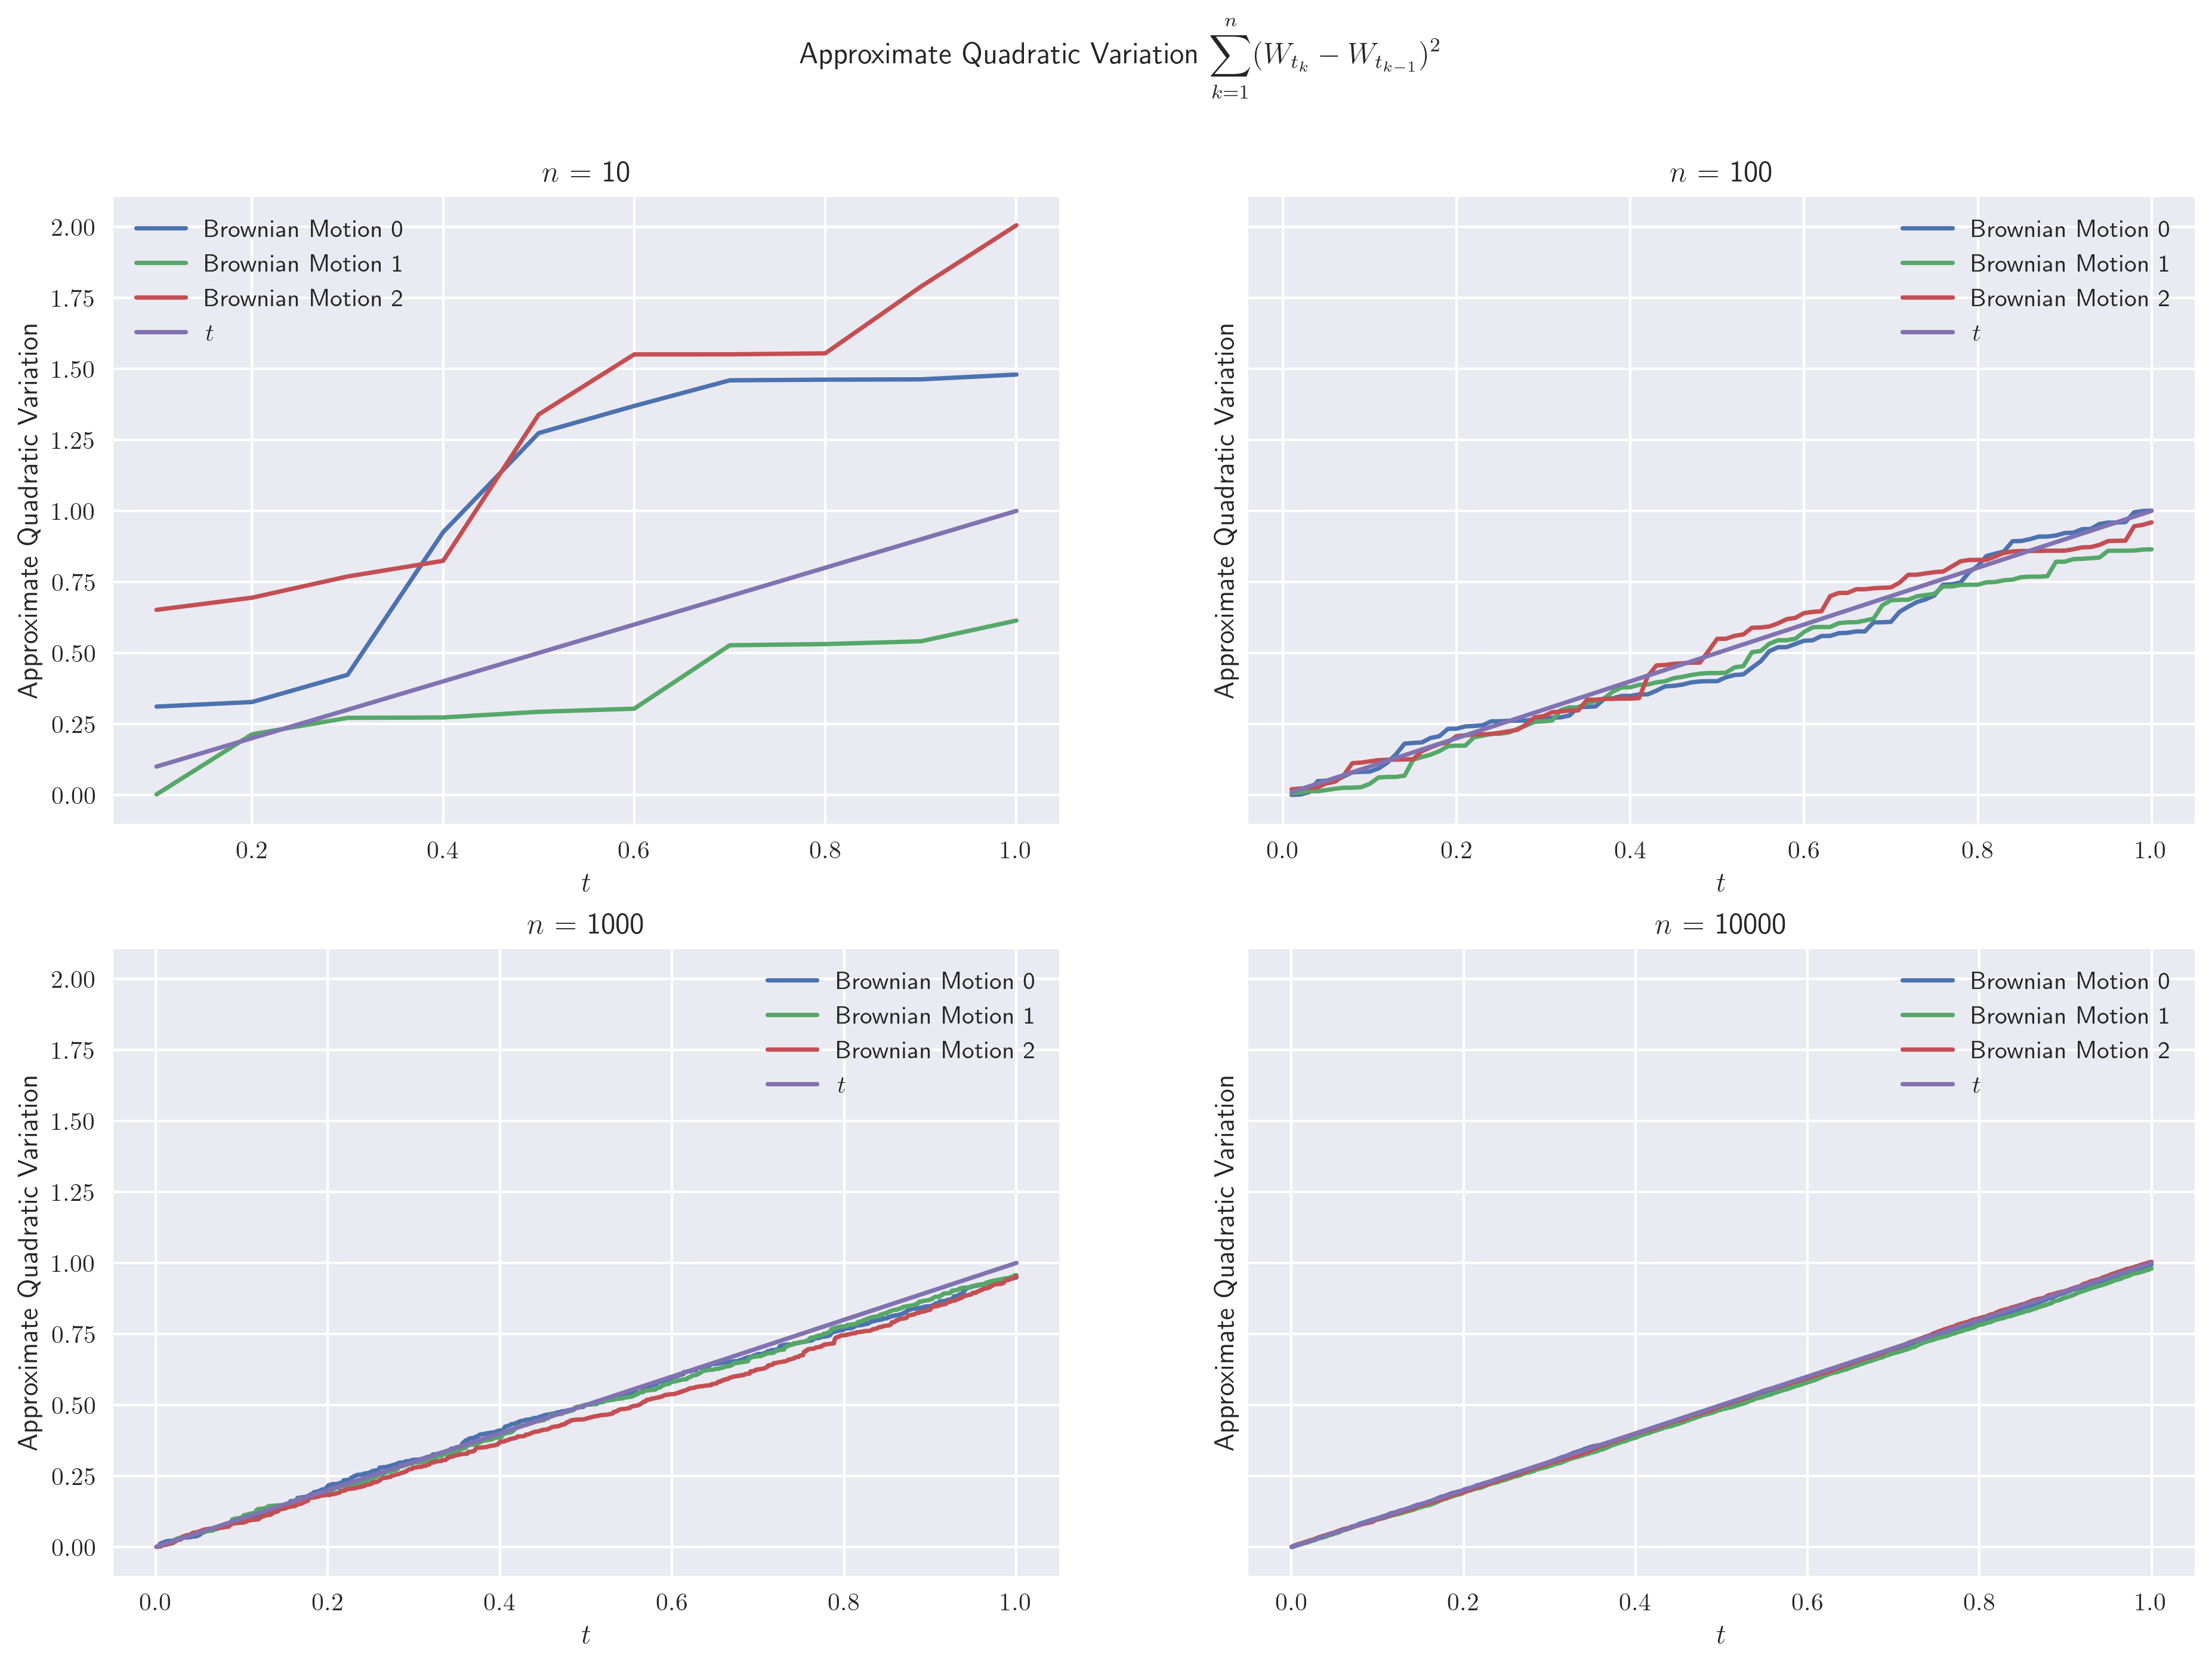

In [31]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Define n-values
n_vals = [10, 100, 1000, 10000]

# Set up subplots
fig, ax = plt.subplots(2, 2, sharey = True, figsize = (15, 10))

# Simulate five Brownian motions
for i, n in enumerate(n_vals):
    
    # Get row and column
    row, col = i//2, i % 2
    
    # Difference of two Brownian motions is normal
    dW = norm.rvs(scale = np.sqrt(1/n), size = (3, n))
    
    # Calculate quadratic variance
    quad_var = np.cumsum(dW**2, axis = 1)
    
    # Plot results
    for j in range(3):
        
        ax[row, col].plot(np.linspace(1/n, 1, n), quad_var[j, :], label = f'Brownian Motion {j}')

    # Plot t
    ax[row, col].plot(np.linspace(1/n, 1, n), np.linspace(1/n, 1, n), 
         label = r'$t$')
    
    # Add x-label
    ax[row, col].set_xlabel(r'$t$')

    # Add y-label
    ax[row, col].set_ylabel(r'Approximate Quadratic Variation')
    
    # Give plot a title
    ax[row, col].set_title(f'$n$ = {n}')
    
    # Add legend
    ax[row, col].legend()

# Add title to plot
plt.suptitle(r'Approximate Quadratic Variation $\displaystyle\sum_{k = 1}^{n} (W_{t_k} - W_{t_{k - 1}})^2$')

# Save the figure
plt.savefig(path + r'ex4-8.png')

plt.show()

In [45]:
# Import modules
import numpy as np
from scipy.stats import norm

# Set the random seed
np.random.seed(0)

# Set n, so there are n + 1 places where BM exact
n = 1_000_000

# Define T
T = 1

# Simulate independent increment
dW = norm.rvs(scale = np.sqrt(T/n), size = n)

# Sum up to get BM
W = np.insert(np.cumsum(dW), 0, 0)

# Approximate Ito integral; using left endpoints
integral_simulated = np.sum(W[0:-1] * dW)

# Write analytic result
integral_analytic = 1/2 * W[-1]**2 - T/2

print(f'The simulated result is {integral_simulated:.3f} while the analytic result is {integral_analytic:.3f}.')

The simulated result is 0.643 while the analytic result is 0.643.
